# 02 · Feature Engineering

The raw data gives six monthly snapshots (bills, payments, repayment status). The strongest
signals for default are **behavioural ratios across that window** — credit utilization,
payment coverage, and delinquency dynamics — none of which exist as raw columns.

This notebook builds and validates the production feature pipeline from `src.features`:

1. `FinancialFeatureEngineer` — appends 15 derived features (row-wise, **stateless**).
2. A `ColumnTransformer` — **median-imputes + scales** numeric columns and **encodes**
   categoricals (one-hot vs. target encoding by cardinality).

The pipeline is **fit on the training split only**; the test split is transformed with
training-learned statistics, so there is no leakage.

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

_root = Path.cwd()
while not (_root / "pyproject.toml").exists() and _root != _root.parent:
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

from src.data.dataset import ALL_FEATURES, CATEGORICAL_FEATURES, TARGET_COLUMN, load_splits
from src.features import (
    DERIVED_FEATURE_DESCRIPTIONS,
    DERIVED_FEATURES,
    FinancialFeatureEngineer,
    build_feature_pipeline,
    get_feature_names,
)
from src.features.pipeline import _split_categoricals_by_cardinality
from src.utils.config import get_settings
from src.viz.style import PALETTE, apply_style, colors, compose, format_number, grid, label_bars, percent

warnings.filterwarnings("ignore", category=FutureWarning)
apply_style()  # NyxAI Editorial v3: dark paper, cream ink, green as the only accent
pd.set_option("display.max_columns", 60)

settings = get_settings()
REPORTS = settings.reports_dir / "features"
REPORTS.mkdir(parents=True, exist_ok=True)
SOURCE = "Source: Default of Credit Card Clients, UCI ML Repository, id 350"

train, test = load_splits()
X_train, y_train = train[list(ALL_FEATURES)], train[TARGET_COLUMN]
X_test, y_test = test[list(ALL_FEATURES)], test[TARGET_COLUMN]
print(f"train: {X_train.shape}  test: {X_test.shape}")

train: (24000, 23)  test: (6000, 23)


## 1 · The derived features

`FinancialFeatureEngineer` is a scikit-learn transformer. Because each output depends only
on a single row, it is safe to apply before any train/test split.

In [2]:
engineer = FinancialFeatureEngineer(keep_original=True)
engineered = engineer.fit_transform(X_train)
print(f"{X_train.shape[1]} raw features -> {engineered.shape[1]} "
      f"({len(DERIVED_FEATURES)} engineered added)")
engineered[list(DERIVED_FEATURES)].head()

23 raw features -> 38 (15 engineered added)


,util_mean,util_max,util_last,bill_total,pay_total,payment_ratio_total,payment_ratio_mean,num_delayed_months,max_delay,mean_delay,recent_delay,delay_trend,bill_trend,has_any_delay,credit_per_age
0,1.034312,1.078950,1.011069,992940,39500,0.039781,0.040480,4,3,1.500000,2,2,-1234,1,4848.484848
1,0.000059,0.000353,0.000000,53,53,1.000000,8.833333,1,1,-1.166667,1,3,0,1,4411.764706
2,0.857683,1.017100,1.017100,51461,4016,0.078040,0.080701,2,2,0.500000,1,1,1771,1,200.000000
3,0.846647,0.993241,0.940359,1117574,41687,0.037301,0.037856,0,0,0.000000,0,0,72533,0,7586.206897
4,0.000098,0.001052,0.000000,182,1526,8.384615,254.333333,1,1,-0.666667,1,3,235,1,9687.500000


In [3]:
# Catalogue of engineered features.
catalog = pd.DataFrame(
    [(f, DERIVED_FEATURE_DESCRIPTIONS[f]) for f in DERIVED_FEATURES],
    columns=["feature", "description"],
)
catalog

,feature,description
0,util_mean,Mean credit utilization over 6 months (avg bil...
1,util_max,Peak monthly credit utilization (max bill / cr...
2,util_last,Most recent month's credit utilization (BILL_A...
3,bill_total,Total amount billed across the 6-month window
4,pay_total,Total amount paid across the 6-month window
5,payment_ratio_total,Debt-service coverage: total paid / total billed
6,payment_ratio_mean,Average of per-month payment-to-bill coverage ...
7,num_delayed_months,Number of months with a payment delay (PAY_i >...
8,max_delay,Worst repayment-status value in the window (mo...
9,mean_delay,Average repayment-status value across the window


## 2 · Do the engineered features carry signal?

We compare each engineered feature's univariate ROC AUC against the target. Several derived
features (utilization, delinquency counts, recent delay) rival or exceed the best raw
features — confirming the engineering adds value.

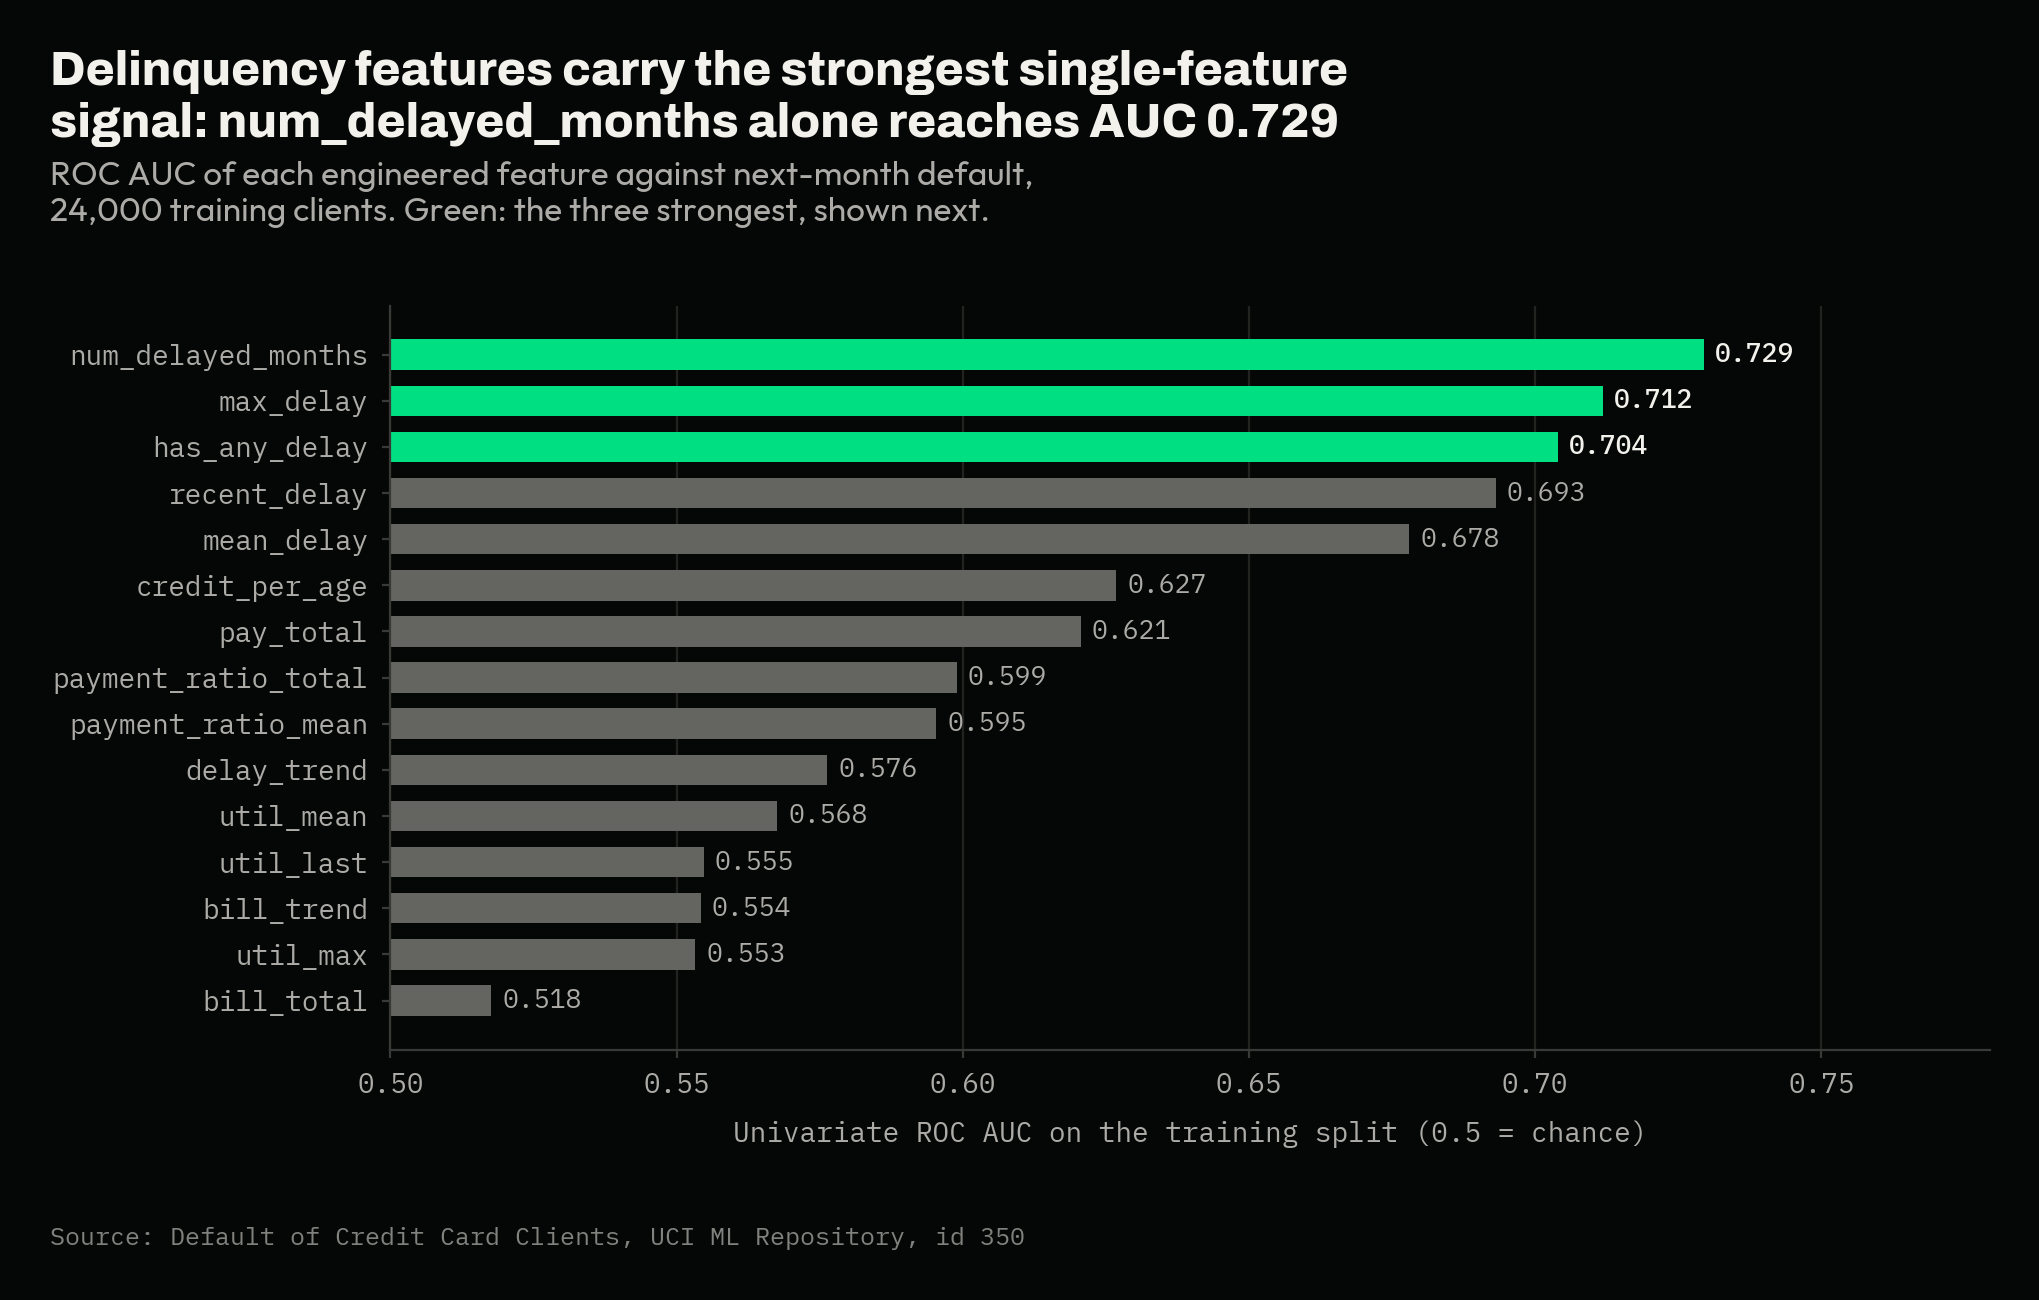

,feature,auc
0,num_delayed_months,0.729
1,max_delay,0.712
2,has_any_delay,0.704
3,recent_delay,0.693
4,mean_delay,0.678
5,credit_per_age,0.627
6,pay_total,0.621
7,payment_ratio_total,0.599
8,payment_ratio_mean,0.595
9,delay_trend,0.576


In [4]:
eng_for_auc = engineered.assign(**{TARGET_COLUMN: y_train.values})
rows = []
for f in DERIVED_FEATURES:
    col = eng_for_auc[f].replace([np.inf, -np.inf], np.nan)
    mask = col.notna()
    auc = roc_auc_score(eng_for_auc.loc[mask, TARGET_COLUMN], col[mask])
    rows.append((f, max(auc, 1 - auc)))
auc_df = pd.DataFrame(rows, columns=["feature", "auc"]).sort_values("auc", ascending=False)

top = auc_df["feature"].head(3).tolist()
fig, ax = plt.subplots(figsize=(10, 6.4))
bars = ax.barh(auc_df["feature"], auc_df["auc"], height=0.66, color=colors(auc_df["feature"], top))
label_bars(ax, bars, [f"{a:.3f}" for a in auc_df["auc"]], highlight={0, 1, 2})
ax.invert_yaxis()
ax.set_xlim(0.5, auc_df["auc"].max() + 0.05)
ax.set_xlabel("Univariate ROC AUC on the training split (0.5 = chance)")
grid(ax, "x")
compose(
    fig,
    "Delinquency features carry the strongest single-feature signal: "
    f"{top[0]} alone reaches AUC {auc_df['auc'].iloc[0]:.3f}",
    f"ROC AUC of each engineered feature against next-month default, {len(X_train):,} training "
    "clients. Green: the three strongest, shown next.",
    SOURCE,
)
fig.savefig(REPORTS / "engineered_feature_auc.png")
plt.show()
display(auc_df.round(3).reset_index(drop=True))

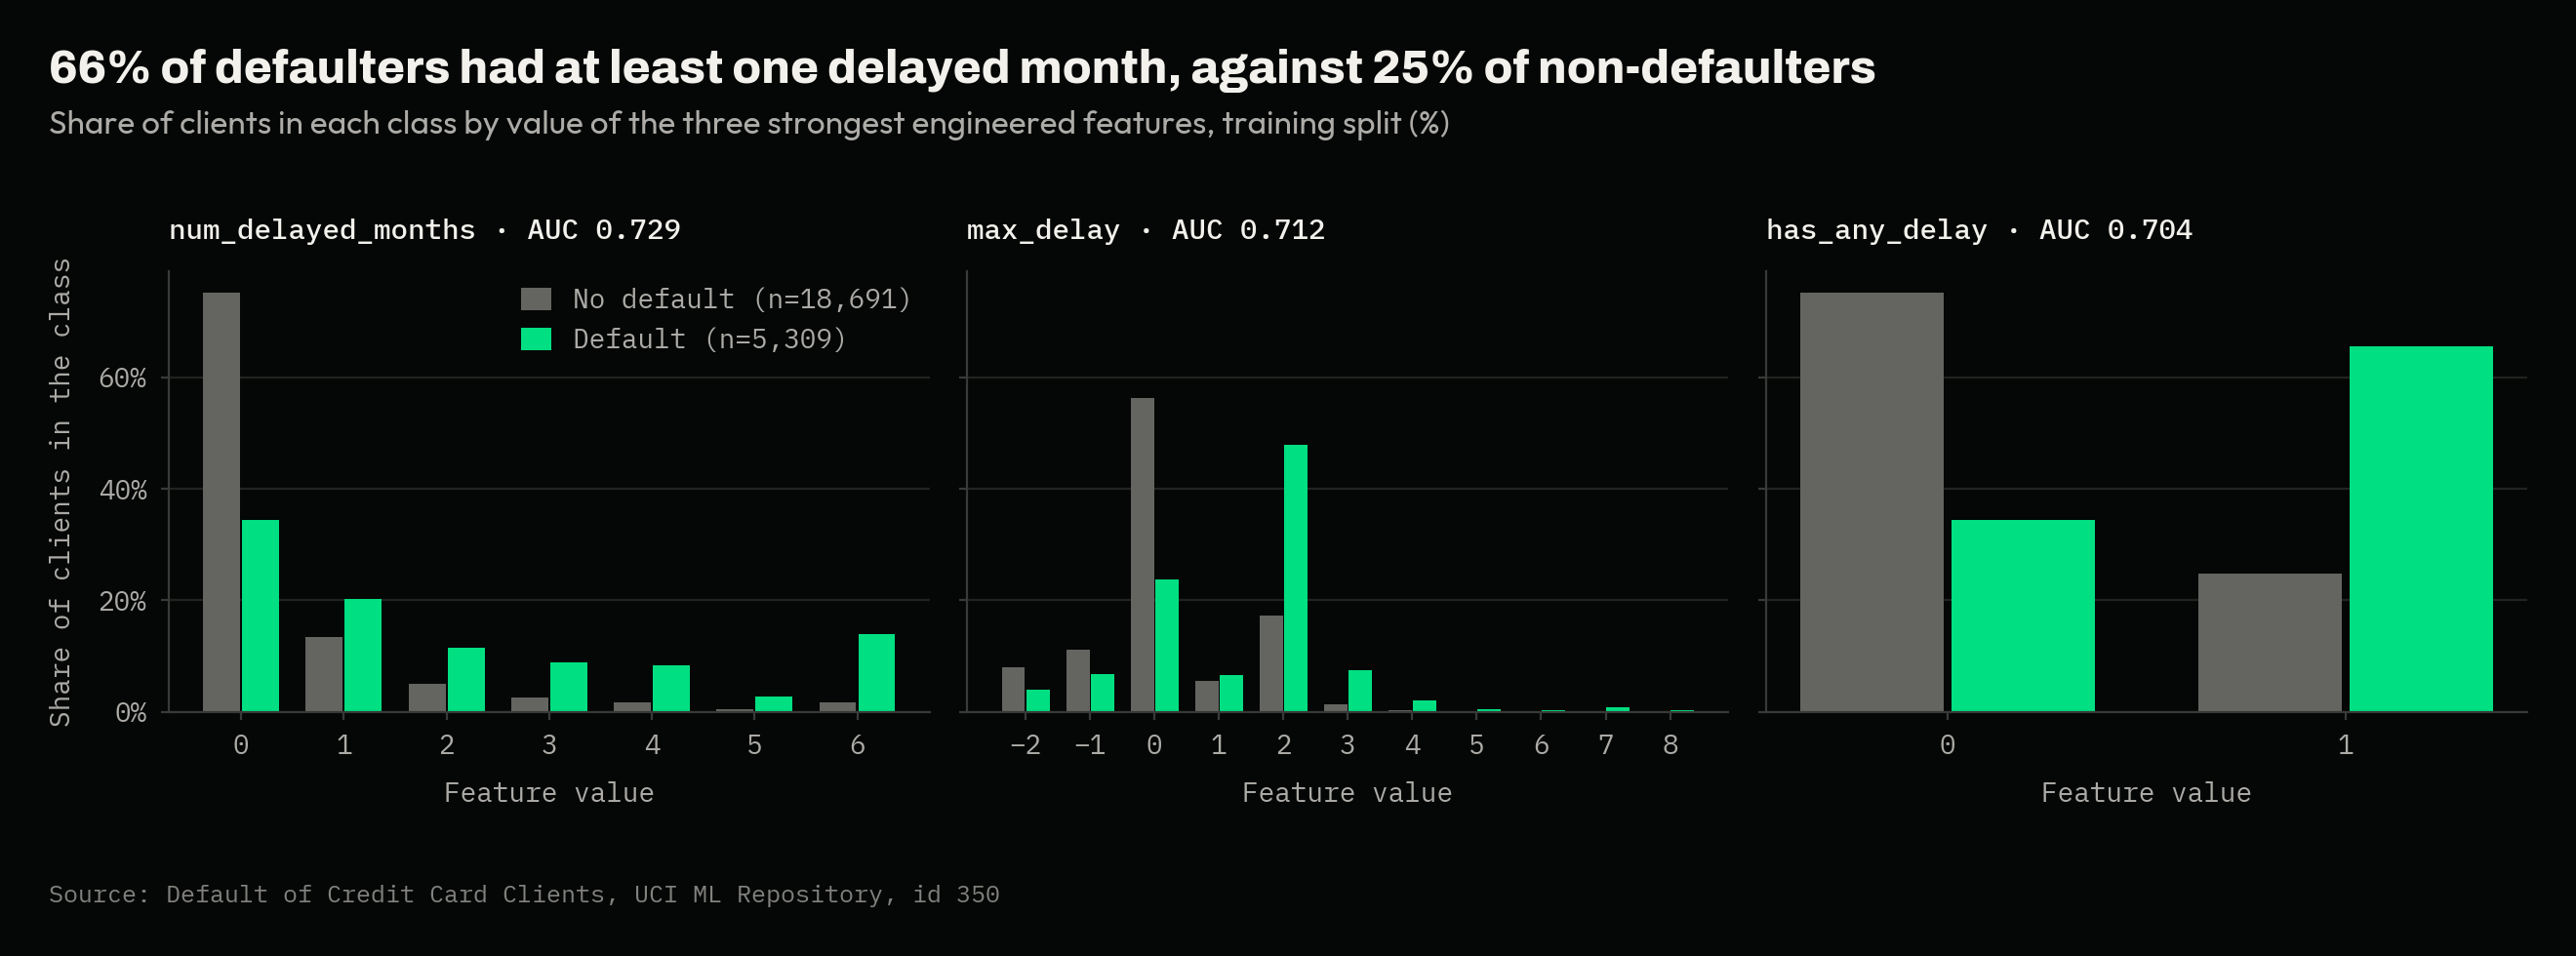

In [5]:
# How the three strongest engineered features separate the classes. They take a handful of
# integer values, so the honest picture is the share of each class at every value.
top = auc_df["feature"].head(3).tolist()
auc_by_feature = auc_df.set_index("feature")["auc"]
y = y_train.to_numpy()
classes = [(0, "No default", PALETTE["neutral"], -0.19), (1, "Default", PALETTE["green"], 0.19)]
any_delay = engineered["has_any_delay"].to_numpy()
share_delay = {cls: any_delay[y == cls].mean() for cls in (0, 1)}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.8), sharey=True)
for ax, f in zip(axes, top):
    share = pd.crosstab(engineered[f].to_numpy(), y, normalize="columns")
    x = np.arange(len(share))
    for cls, name, color, offset in classes:
        ax.bar(x + offset, share[cls], width=0.36, color=color,
               label=f"{name} (n={int((y == cls).sum()):,})")
    ax.set_xticks(x, [format_number(v) for v in share.index])
    ax.set_title(f"{f} · AUC {auc_by_feature[f]:.3f}")
    ax.set_xlabel("Feature value")
    percent(ax, "y", nbins=5)
    grid(ax, "y")
axes[0].set_ylabel("Share of clients in the class")
axes[0].legend(loc="upper right")
compose(
    fig,
    f"{share_delay[1]:.0%} of defaulters had at least one delayed month, "
    f"against {share_delay[0]:.0%} of non-defaulters",
    "Share of clients in each class by value of the three strongest engineered features, "
    "training split (%)",
    SOURCE,
)
fig.savefig(REPORTS / "engineered_top_distributions.png")
plt.show()

## 3 · Encoder selection by cardinality

Low-cardinality categoricals are one-hot encoded; anything above the threshold (default 10)
would use scikit-learn's `TargetEncoder` (with internal CV to avoid leakage). All three
categoricals here are low-cardinality, so all are one-hot encoded — but the logic generalises.

In [6]:
onehot_cols, target_cols = _split_categoricals_by_cardinality(train, threshold=10)
card = pd.DataFrame(
    [(c, int(train[c].nunique()), "one-hot" if c in onehot_cols else "target")
     for c in CATEGORICAL_FEATURES],
    columns=["feature", "cardinality", "encoder"],
)
card

,feature,cardinality,encoder
0,SEX,2,one-hot
1,EDUCATION,4,one-hot
2,MARRIAGE,3,one-hot


## 4 · The full pipeline — fit on train, transform both

`build_feature_pipeline` chains the engineer and the column transformer. We fit on the
training split only and transform both splits.

In [7]:
pipe = build_feature_pipeline(train, scale=True)
pipe.fit(X_train, y_train)              # learns impute medians, scaler stats, encodings

Z_train = pipe.transform(X_train)
Z_test = pipe.transform(X_test)
feature_names = get_feature_names(pipe)

print(f"Output matrix: train {Z_train.shape}, test {Z_test.shape}")
print(f"Output features: {len(feature_names)}")
assert not np.isnan(Z_train.to_numpy()).any(), "NaNs leaked into the output!"
assert not np.isnan(Z_test.to_numpy()).any(), "NaNs leaked into the output!"
print("No NaNs in either matrix ✅")
Z_train.iloc[:3, :8]

Output matrix: train (24000, 43), test (6000, 43)
Output features: 43
No NaNs in either matrix ✅


,LIMIT_BAL,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
0,-0.056866,-0.264558,1.793311,1.780193,2.652046,1.911811,0.240260,0.256087
1,-0.134081,-0.155804,0.902944,-0.722324,-0.697642,-1.530826,-1.537252,-1.489963
2,-1.215090,1.584260,0.902944,1.780193,0.139780,0.190493,0.240260,0.256087


In [8]:
# Numeric columns are standardised on TRAIN (mean~0, std~1); TEST uses train stats
# (so test mean/std need NOT be exactly 0/1 — that is the correct, leakage-free behaviour).
num_cols = [c for c in feature_names if c in (*ALL_FEATURES, *DERIVED_FEATURES)][:6]
check = pd.DataFrame({
    "train_mean": Z_train[num_cols].mean().round(3),
    "train_std": Z_train[num_cols].std().round(3),
    "test_mean": Z_test[num_cols].mean().round(3),
    "test_std": Z_test[num_cols].std().round(3),
})
display(check)
print("Train means ~0 and stds ~1; test differs slightly -> confirms no leakage.")

,train_mean,train_std,test_mean,test_std
LIMIT_BAL,0.0,1.0,0.005,1.009
AGE,-0.0,1.0,0.029,1.012
PAY_1,0.0,1.0,-0.011,1.003
PAY_2,-0.0,1.0,0.001,0.993
PAY_3,-0.0,1.0,0.003,1.011
PAY_4,0.0,1.0,0.003,1.031


Train means ~0 and stds ~1; test differs slightly -> confirms no leakage.


## 5 · Persist the feature manifest

The ordered output feature names are saved for the docs / model card and to assert pipeline stability in tests.

In [9]:
import json
manifest = {
    "n_input_features": len(ALL_FEATURES),
    "n_engineered_features": len(DERIVED_FEATURES),
    "n_output_features": len(feature_names),
    "output_feature_names": feature_names,
    "engineered_features": list(DERIVED_FEATURES),
}
out_path = settings.processed_data_dir / "feature_manifest.json"
out_path.write_text(json.dumps(manifest, indent=2) + "\n")
print(f"Wrote {out_path.relative_to(settings.repo_root)}")
print(f"{manifest['n_input_features']} raw -> {manifest['n_output_features']} model-ready features")

Wrote data/processed/feature_manifest.json
23 raw -> 43 model-ready features


## Key takeaways

- **15 engineered features** capture utilization, payment coverage, and delinquency dynamics;
  several have higher univariate AUC than any raw column.
- The pipeline outputs **43 model-ready features** (35 numeric + 8 one-hot) with **zero NaNs**.
- **Median imputation + standardisation** make the matrix safe for linear models; trees ignore
  the scaling.
- Encoders are chosen **by cardinality** (one-hot here; target encoding wired in for high-card).
- **Leakage-free by construction**: stateless engineering + a pipeline fit on training folds only.
  This same pipeline object is fit inside cross-validation in Phase 3.